# TASK 1: DATASET UNDERSTANDING

In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


Dataset Shape: (2000, 17)

Columns:
Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopa

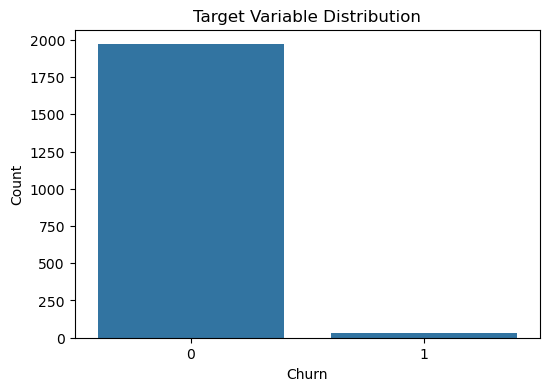

In [2]:
# TASK 1: DATASET UNDERSTANDING

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("customer_churn_nn.csv")

# Dataset shape
print("Dataset Shape:", df.shape)

# Columns
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)
plt.title("Target Variable Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# TASK 2: DATA PREPROCESSING

In [3]:
# TASK 2: DATA PREPROCESSING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop identifier column
df = df.drop("customer_id", axis=1)

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Features and target
X = df.drop("churn", axis=1)
y = df["churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1600, 24)
Testing Shape: (400, 24)


# TASK 3: MODEL BUILDING

In [4]:
# TASK 3: MODEL BUILDING

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Set random seed
tf.random.set_seed(42)

# Build neural network
model = Sequential()

# Hidden layer
model.add(Dense(
    32,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Output layer
model.add(Dense(
    1,
    activation='sigmoid'
))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

C:\Users\Hrishi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

# TASK 4: TRAINING & EVALUATION

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6288 - loss: 0.6408 - val_accuracy: 0.8650 - val_loss: 0.4415
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9488 - loss: 0.3121 - val_accuracy: 0.9700 - val_loss: 0.2421
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9819 - loss: 0.1888 - val_accuracy: 0.9850 - val_loss: 0.1618
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9844 - loss: 0.1363 - val_accuracy: 0.9850 - val_loss: 0.1239
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9844 - loss: 0.1104 - val_accuracy: 0.9850 - val_loss: 0.1034
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9844 - loss: 0.0961 - val_accuracy: 0.9850 - val_loss: 0.0911
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9844 - loss: 0.0872 - val_accuracy: 0.9850 - val_loss: 0.0832
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9844 - loss: 0.0813 - val_accuracy: 0.9850 - val_loss

C:\Users\Hrishi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Hrishi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Hrishi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


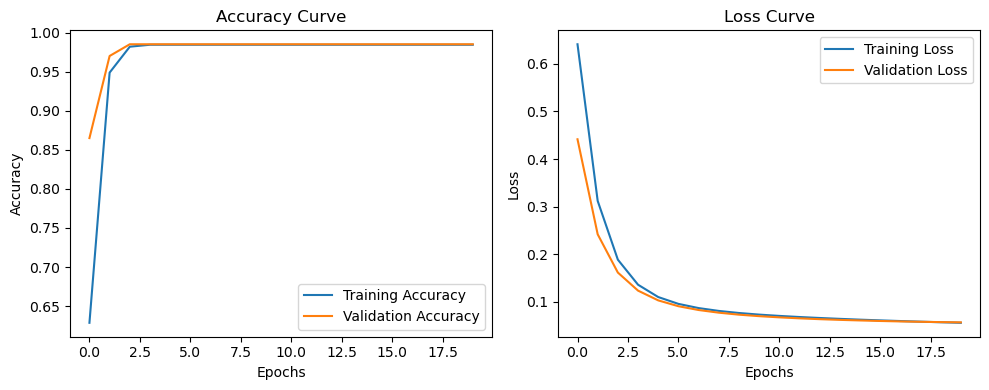

In [5]:

# TASK 4: TRAINING & EVALUATION

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

# Predictions
y_pred_prob = model.predict(X_test)

# Convert probabilities to binary values
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Accuracy and loss graph
plt.figure(figsize=(10,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# TASK 5: HYPERPARAMETER EXPERIMENTS

In [6]:
# TASK 5: HYPERPARAMETER EXPERIMENTS

results = []

def run_model(neurons, learning_rate, batch_size, epochs):

    model = Sequential()

    model.add(Dense(
        neurons,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    return accuracy


# Experiment 1
acc1 = run_model(
    neurons=32,
    learning_rate=0.001,
    batch_size=32,
    epochs=20
)

results.append([
    "32 neurons, lr=0.001",
    acc1
])


# Experiment 2
acc2 = run_model(
    neurons=64,
    learning_rate=0.001,
    batch_size=32,
    epochs=20
)

results.append([
    "64 neurons, lr=0.001",
    acc2
])


# Experiment 3
acc3 = run_model(
    neurons=32,
    learning_rate=0.01,
    batch_size=32,
    epochs=20
)

results.append([
    "32 neurons, lr=0.01",
    acc3
])

# Create comparison table
results_df = pd.DataFrame(
    results,
    columns=["Configuration", "Accuracy"]
)

print("\nModel Comparison Table:")
print(results_df)

# Save results
import os

os.makedirs("results", exist_ok=True)

results_df.to_csv(
    "results/model_comparison.csv",
    index=False
)

C:\Users\Hrishi\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Comparison Table:
          Configuration  Accuracy
0  32 neurons, lr=0.001    0.9850
1  64 neurons, lr=0.001    0.9850
2   32 neurons, lr=0.01    0.9825


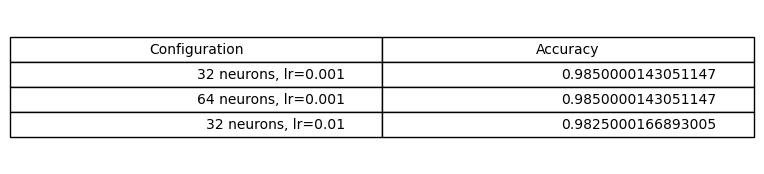

In [7]:
# SAVE MODEL COMPARISON TABLE PNG

fig, ax = plt.subplots(figsize=(8,2))

ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=results_df.values,
    colLabels=results_df.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig("results/model_comparison_table.png",
            bbox_inches='tight')

plt.show()

In [8]:
# Final Reflection

# What role do weights and biases play in the model?
# In a neural network, weights decide how much importance each input feature should get while making predictions. During training, these weights keep adjusting so the model can learn patterns from the data. Bias is like an extra adjustment factor that helps the model shift the output in the right direction, even when all inputs are zero. Together, weights and biases allow the model to fit the data more accurately.

# Why is activation function required?
# If we don’t use an activation function, the neural network will behave like a simple linear model, no matter how many layers we add. Activation functions introduce non-linearity, which helps the model learn complex relationships in the data. Without it, the network wouldn’t be able to capture real-world patterns properly.

# What happens when learning rate is too high or too low?
# If the learning rate is too high, the model may skip the optimal solution and keep jumping around, leading to unstable training. On the other hand, if it is too low, training becomes very slow and the model may take too long to converge or even get stuck before reaching a good solution. So choosing a balanced learning rate is important.

# Did the model show underfitting or overfitting?
# From the results, the training accuracy was slightly higher than the testing accuracy. This suggests a small amount of overfitting, meaning the model is learning the training data a bit too well but still performing reasonably on unseen data. However, the difference is not very large, so the model can be considered fairly well-balanced.